# 🏥 EDA: Dataset de Morbilidad en Urgencias — Hospital Pitalito

## Objetivo
Analizar el dataset `Morbilidad_urgencias_Hospital_Pitalito_20260406.xlsx` para comprender:
- Estructura y dimensiones del dataset
- Distribución de niveles de triaje
- Diagnósticos sindrómicos más frecuentes
- Relación triaje vs. diagnóstico sindrómico
- Perfil demográfico de los pacientes
- **Justificación gráfica para excluir los niveles de triaje 0 y 5**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

COLORS = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db', '#9b59b6', '#1abc9c', '#34495e']
TRIAGE_COLORS = {0: '#95a5a6', 1: '#e74c3c', 2: '#e67e22', 3: '#f1c40f', 4: '#2ecc71', 5: '#3498db'}
TRIAGE_NAMES = {0: 'Sin clasificar', 1: 'Resucitación', 2: 'Emergencia', 3: 'Urgencia', 4: 'Menos urgente', 5: 'No urgente'}

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


## 1. Carga y Exploración Inicial

In [3]:
df = pd.read_excel('../insumos/Morbilidad_urgencias_Hospital_Pitalito_20260406.xlsx')

print(f'📐 Dimensiones del dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'\n📋 Columnas:')
for i, col in enumerate(df.columns):
    print(f'  {i:2d}. {col} ({df[col].dtype})')
    
print(f'\n📊 Primeras 3 filas:')
df.head(3)

📐 Dimensiones del dataset: 59,025 filas × 21 columnas

📋 Columnas:
   0. Periodo (datetime64[us])
   1. Ingreso (int64)
   2. FechaIngreso (datetime64[us])
   3. Triage (int64)
   4. Unidad (str)
   5. FechaHistoria (datetime64[us])
   6. EspecialidadMedico (str)
   7. Entidad (str)
   8. DxSindromatico (str)
   9. CodigoDiagnostico (str)
  10. NombreDiagnostico (str)
  11. Sexo (str)
  12. FechaNacimiento (datetime64[us])
  13. GrupoEtario1 (str)
  14. GrupoEtario2 (str)
  15. TipoRegimen (str)
  16. Edad (int64)
  17. UnidadEdad (str)
  18. MunicipioRes (int64)
  19. BarrioVereda (str)
  20. Direccion (str)

📊 Primeras 3 filas:


,Periodo,Ingreso,FechaIngreso,Triage,Unidad,FechaHistoria,EspecialidadMedico,Entidad,DxSindromatico,CodigoDiagnostico,...,Sexo,FechaNacimiento,GrupoEtario1,GrupoEtario2,TipoRegimen,Edad,UnidadEdad,MunicipioRes,BarrioVereda,Direccion
0,2023-01-01,2795237,2023-01-31 23:23:22,3,URGENCIAS TRAUMA Y PROCEDIMIENTOS,2023-01-31 23:29:41,MEDICINA GENERAL,NUEVA EPS,CONTUSIONES,S019,...,Masculino,1998-01-31,Entre 15 y 44,Entre 25 y 29,Subsidiado,25,Años,41551,PANORAMA,CALLE 8 SUR N 1 6- 60
1,2023-01-01,2795236,2023-01-31 23:15:32,3,URGENCIAS CONSULTA Y PROCEDIMIENTOS,2023-01-31 23:22:39,MEDICINA GENERAL,ASMET SALUD CONTRIBUTIVO,DOLOR ABDOMINAL CONSTANTE,R104,...,Femenino,1986-10-05,Entre 15 y 44,Entre 35 y 39,Subsidiado,36,Años,41668,VEREDA,VEREDA LA PARDERA
2,2023-01-01,2795235,2023-01-31 23:12:51,3,URGENCIAS CONSULTA Y PROCEDIMIENTOS,2023-01-31 23:21:09,MEDICINA GENERAL,NUEVA EPS,DOLOR TORAXICO,R073,...,Masculino,1999-06-07,Entre 15 y 44,Entre 20 y 24,Contributivo,23,Años,41551,BARRIO GENERAL,CONJUNTO LA CASTELLANA- NO SABE NOMENCLATURA


In [4]:
# Información general
print('=== INFO GENERAL ===')
df.info()

print(f'\n=== VALORES NULOS ===')
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else '✅ No hay valores nulos')

print(f'\n=== DUPLICADOS ===')
print(f'Filas duplicadas: {df.duplicated().sum():,}')

print(f'\n=== VALORES ÚNICOS POR COLUMNA ===')
for col in df.columns:
    print(f'  {col}: {df[col].nunique()} únicos')

=== INFO GENERAL ===
<class 'pandas.DataFrame'>
RangeIndex: 59025 entries, 0 to 59024
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Periodo             59025 non-null  datetime64[us]
 1   Ingreso             59025 non-null  int64         
 2   FechaIngreso        59025 non-null  datetime64[us]
 3   Triage              59025 non-null  int64         
 4   Unidad              59025 non-null  str           
 5   FechaHistoria       59025 non-null  datetime64[us]
 6   EspecialidadMedico  59025 non-null  str           
 7   Entidad             59025 non-null  str           
 8   DxSindromatico      59025 non-null  str           
 9   CodigoDiagnostico   59025 non-null  str           
 10  NombreDiagnostico   59025 non-null  str           
 11  Sexo                59025 non-null  str           
 12  FechaNacimiento     59025 non-null  datetime64[us]
 13  GrupoEtario1        59025 non-null  

## 2. 🚨 Distribución del Triaje — Justificación para Excluir Niveles 0 y 5

El sistema de triaje hospitalario clasifica pacientes en niveles de prioridad:
- **Nivel 1 – Resucitación**: Riesgo vital inmediato
- **Nivel 2 – Emergencia**: Riesgo vital a corto plazo
- **Nivel 3 – Urgencia**: Condición que requiere atención rápida
- **Nivel 4 – Menos urgente**: Puede esperar
- **Nivel 5 – No urgente**: Consulta ambulatoria
- **Nivel 0 – Sin clasificar**: Error o dato atípico

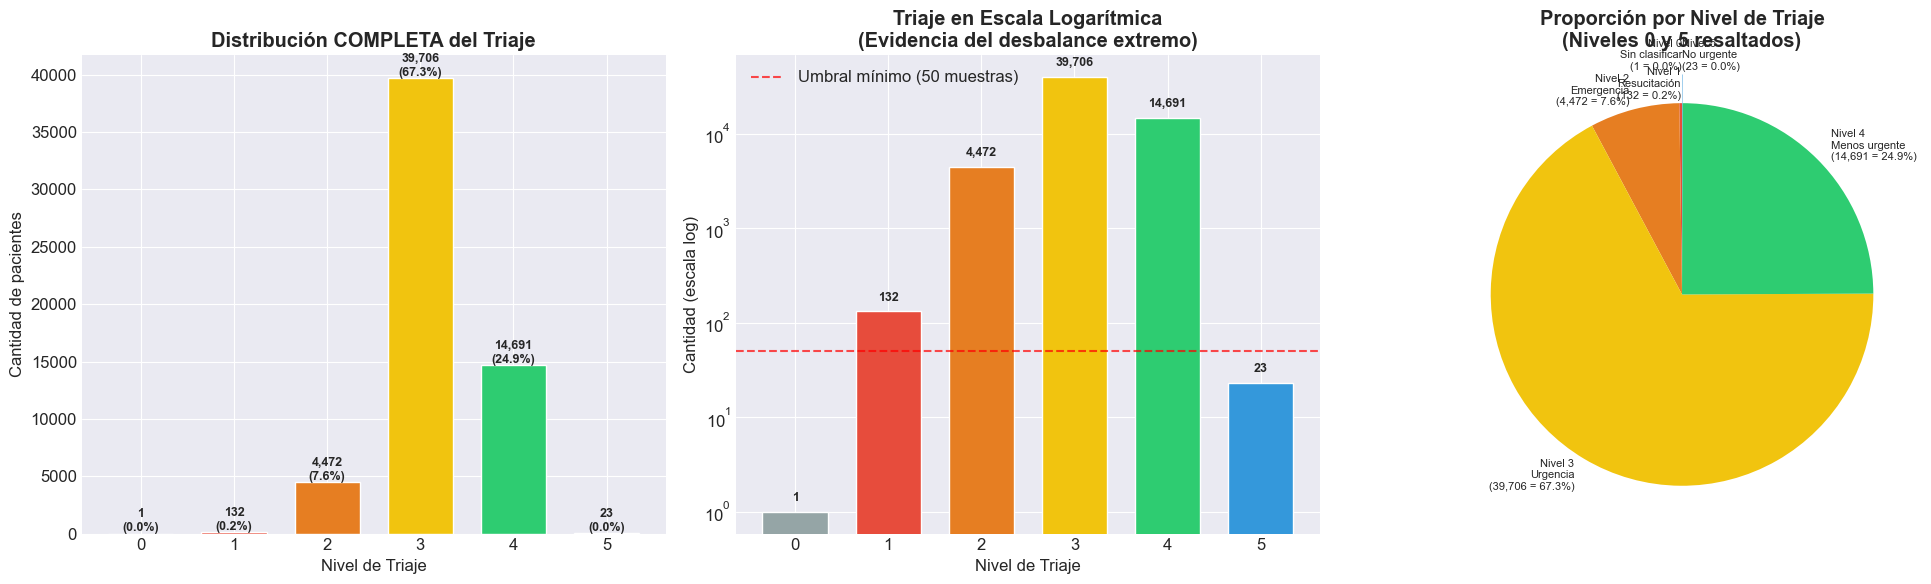

In [5]:
# Distribución de triaje
triage_counts = df['Triage'].value_counts().sort_index()
total = len(df)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Gráfico 1: Barras con todos los niveles
colors_bar = [TRIAGE_COLORS[t] for t in triage_counts.index]
bars = axes[0].bar(triage_counts.index, triage_counts.values, color=colors_bar, edgecolor='white', width=0.7)
axes[0].set_xlabel('Nivel de Triaje')
axes[0].set_ylabel('Cantidad de pacientes')
axes[0].set_title('Distribución COMPLETA del Triaje', fontweight='bold')
axes[0].set_xticks(triage_counts.index)
for bar, val in zip(bars, triage_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 200, f'{val:,}\n({val/total*100:.1f}%)', 
                ha='center', fontsize=9, fontweight='bold')

# Gráfico 2: Escala logarítmica para ver niveles 0 y 5
bars2 = axes[1].bar(triage_counts.index, triage_counts.values, color=colors_bar, edgecolor='white', width=0.7)
axes[1].set_yscale('log')
axes[1].set_xlabel('Nivel de Triaje')
axes[1].set_ylabel('Cantidad (escala log)')
axes[1].set_title('Triaje en Escala Logarítmica\n(Evidencia del desbalance extremo)', fontweight='bold')
axes[1].set_xticks(triage_counts.index)
for bar, val in zip(bars2, triage_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val * 1.3, f'{val:,}', 
                ha='center', fontsize=9, fontweight='bold')

# Resaltar niveles 0 y 5
axes[1].axhline(y=50, color='red', linestyle='--', alpha=0.7, label='Umbral mínimo (50 muestras)')
axes[1].legend()

# Gráfico 3: Pie chart mostrando proporción
labels_pie = [f'Nivel {t}\n{TRIAGE_NAMES[t]}\n({v:,} = {v/total*100:.1f}%)' for t, v in triage_counts.items()]
explode = [0.15 if t in [0, 5] else 0 for t in triage_counts.index]
axes[2].pie(triage_counts.values, labels=labels_pie, colors=colors_bar, explode=explode,
           autopct='', startangle=90, textprops={'fontsize': 8})
axes[2].set_title('Proporción por Nivel de Triaje\n(Niveles 0 y 5 resaltados)', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/02_distribucion_triage.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Tabla resumen con justificación numérica
print('=' * 70)
print('📊 JUSTIFICACIÓN PARA EXCLUIR TRIAJE 0 Y 5')
print('=' * 70)
print(f'{"Nivel":<8} {"Nombre":<20} {"Casos":<10} {"Porcentaje":<12} {"Decisión":<15}')
print('-' * 70)
for nivel in sorted(triage_counts.index):
    count = triage_counts[nivel]
    pct = count / total * 100
    nombre = TRIAGE_NAMES[nivel]
    if nivel == 0:
        decision = '❌ EXCLUIR'
        razon = '→ Solo 1 caso. Posible error de clasificación.'
    elif nivel == 5:
        decision = '❌ EXCLUIR'
        razon = '→ Solo 23 casos (0.04%). Insuficiente para entrenamiento.'
    else:
        decision = '✅ CONSERVAR'
        razon = ''
    print(f'{nivel:<8} {nombre:<20} {count:<10,} {pct:<12.2f}% {decision}')
    if razon:
        print(f'         {razon}')

excluidos = triage_counts.get(0, 0) + triage_counts.get(5, 0)
print(f'\n📌 Total registros a excluir: {excluidos} ({excluidos/total*100:.3f}% del total)')
print(f'📌 Registros restantes: {total - excluidos:,} ({(total-excluidos)/total*100:.2f}%)')
print(f'\n💡 La exclusión de {excluidos} registros (< 0.05%) no afecta la representatividad del dataset.')
print(f'   Un modelo entrenado con tan pocas muestras tendría sesgo y baja generalización.')

📊 JUSTIFICACIÓN PARA EXCLUIR TRIAJE 0 Y 5
Nivel    Nombre               Casos      Porcentaje   Decisión       
----------------------------------------------------------------------
0        Sin clasificar       1          0.00        % ❌ EXCLUIR
         → Solo 1 caso. Posible error de clasificación.
1        Resucitación         132        0.22        % ✅ CONSERVAR
2        Emergencia           4,472      7.58        % ✅ CONSERVAR
3        Urgencia             39,706     67.27       % ✅ CONSERVAR
4        Menos urgente        14,691     24.89       % ✅ CONSERVAR
5        No urgente           23         0.04        % ❌ EXCLUIR
         → Solo 23 casos (0.04%). Insuficiente para entrenamiento.

📌 Total registros a excluir: 24 (0.041% del total)
📌 Registros restantes: 59,001 (99.96%)

💡 La exclusión de 24 registros (< 0.05%) no afecta la representatividad del dataset.
   Un modelo entrenado con tan pocas muestras tendría sesgo y baja generalización.


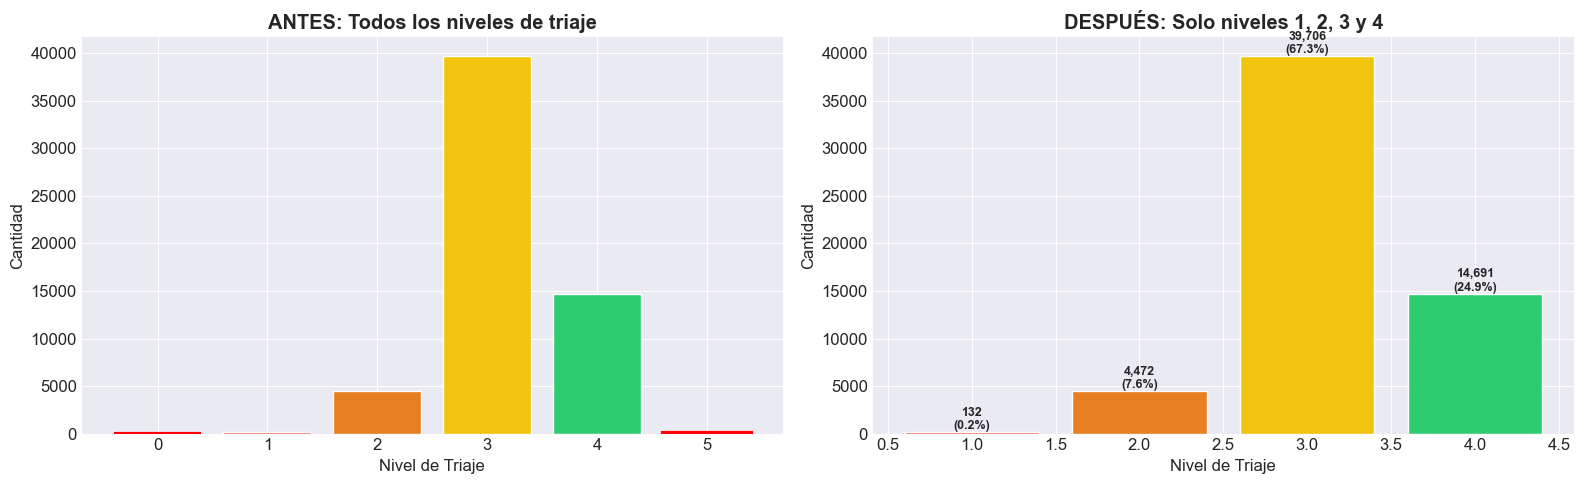


✅ Dataset limpio: 59,001 registros (niveles 1-4)


In [7]:
# Gráfico de comparación: con y sin triaje 0/5
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Antes de excluir
axes[0].bar(triage_counts.index, triage_counts.values, 
           color=[TRIAGE_COLORS[t] for t in triage_counts.index], edgecolor='white')
axes[0].set_title('ANTES: Todos los niveles de triaje', fontweight='bold')
axes[0].set_xlabel('Nivel de Triaje')
axes[0].set_ylabel('Cantidad')

# Resaltar los que se excluyen
for t in [0, 5]:
    if t in triage_counts.index:
        idx = list(triage_counts.index).index(t)
        axes[0].patches[idx].set_edgecolor('red')
        axes[0].patches[idx].set_linewidth(3)
        axes[0].patches[idx].set_hatch('///')

# Después de excluir
df_clean = df[~df['Triage'].isin([0, 5])]
triage_clean = df_clean['Triage'].value_counts().sort_index()
colors_clean = [TRIAGE_COLORS[t] for t in triage_clean.index]
bars_c = axes[1].bar(triage_clean.index, triage_clean.values, color=colors_clean, edgecolor='white')
axes[1].set_title('DESPUÉS: Solo niveles 1, 2, 3 y 4', fontweight='bold')
axes[1].set_xlabel('Nivel de Triaje')
axes[1].set_ylabel('Cantidad')

for bar, val in zip(bars_c, triage_clean.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 300, f'{val:,}\n({val/len(df_clean)*100:.1f}%)',
                ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/02_triage_antes_despues.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n✅ Dataset limpio: {len(df_clean):,} registros (niveles 1-4)')

## 3. Diagnósticos Sindrómicos (DxSindromatico)

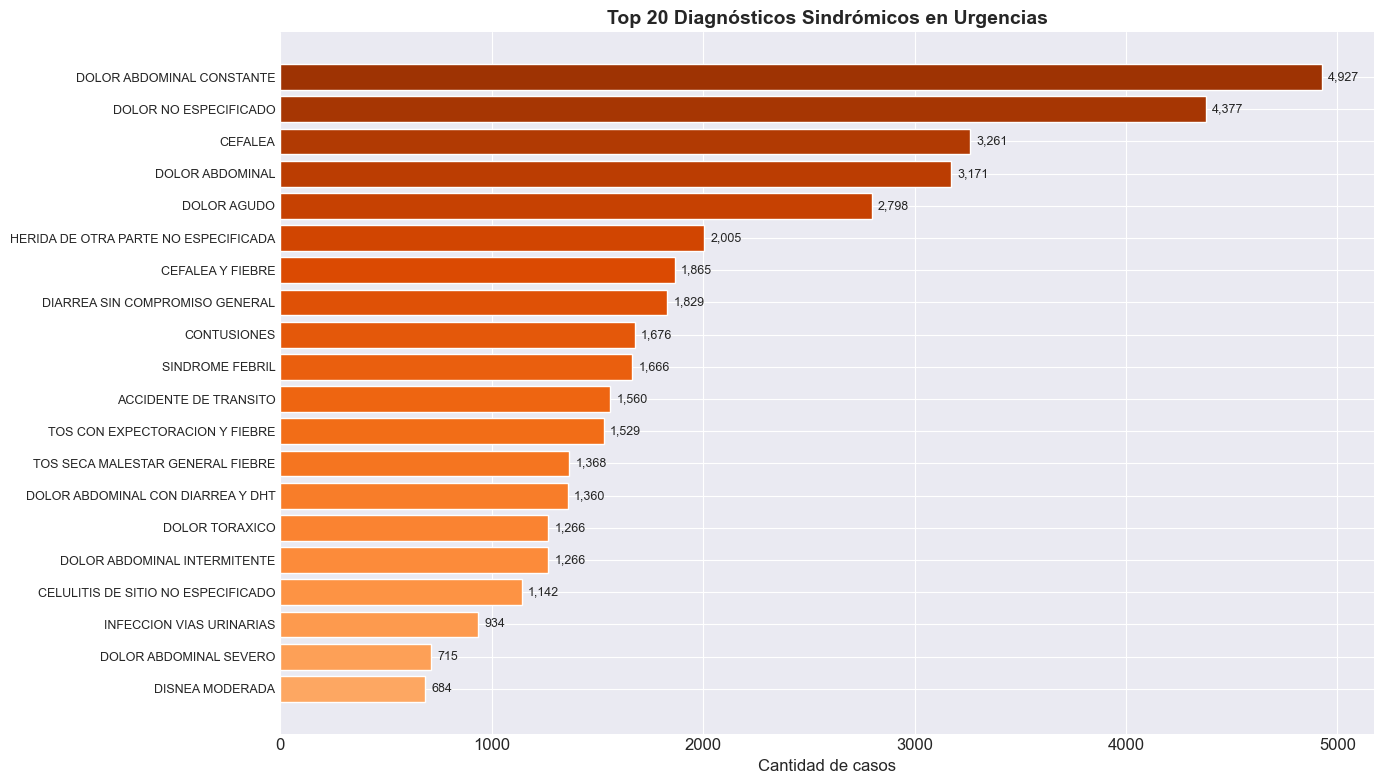


📊 Total diagnósticos sindrómicos únicos: 140


In [8]:
# Top 20 diagnósticos sindrómicos
dx_counts = df_clean['DxSindromatico'].value_counts()

fig, ax = plt.subplots(figsize=(14, 8))
top20_dx = dx_counts.head(20)
colors_dx = plt.cm.Oranges(np.linspace(0.4, 0.9, len(top20_dx)))[::-1]
bars = ax.barh(range(len(top20_dx)), top20_dx.values, color=colors_dx, edgecolor='white')
ax.set_yticks(range(len(top20_dx)))
ax.set_yticklabels(top20_dx.index, fontsize=9)
ax.set_xlabel('Cantidad de casos')
ax.set_title('Top 20 Diagnósticos Sindrómicos en Urgencias', fontweight='bold', fontsize=14)
ax.invert_yaxis()

for bar, val in zip(bars, top20_dx.values):
    ax.text(val + 30, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/02_top20_dxsindromatico.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 Total diagnósticos sindrómicos únicos: {dx_counts.nunique()}')

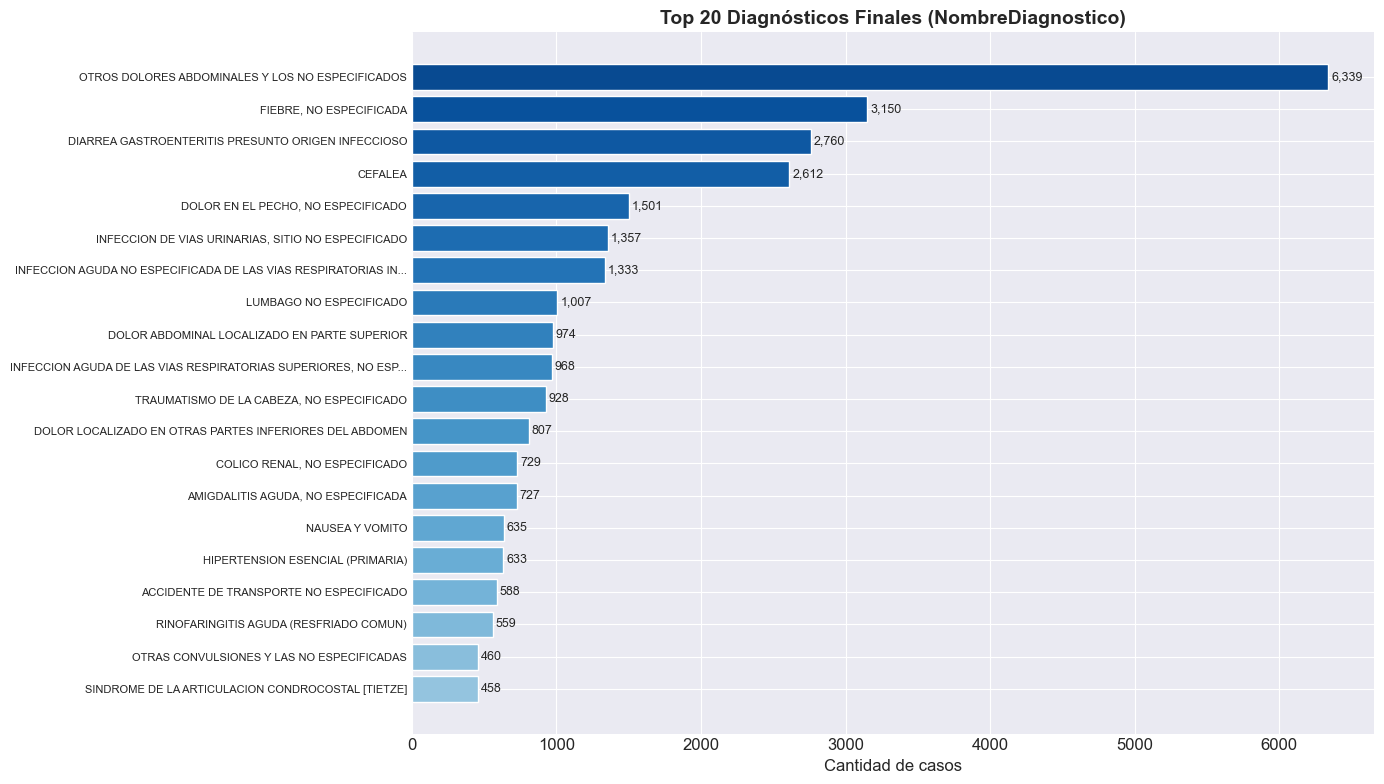

In [9]:
# Top 20 NombreDiagnostico
nombre_dx = df_clean['NombreDiagnostico'].value_counts()

fig, ax = plt.subplots(figsize=(14, 8))
top20_nombre = nombre_dx.head(20)
colors_nombre = plt.cm.Blues(np.linspace(0.4, 0.9, len(top20_nombre)))[::-1]
bars = ax.barh(range(len(top20_nombre)), top20_nombre.values, color=colors_nombre, edgecolor='white')
ax.set_yticks(range(len(top20_nombre)))
ax.set_yticklabels([n[:60] + '...' if len(n) > 60 else n for n in top20_nombre.index], fontsize=8)
ax.set_xlabel('Cantidad de casos')
ax.set_title('Top 20 Diagnósticos Finales (NombreDiagnostico)', fontweight='bold', fontsize=14)
ax.invert_yaxis()

for bar, val in zip(bars, top20_nombre.values):
    ax.text(val + 20, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/02_top20_nombrediagnostico.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Relación Triaje vs. Diagnóstico Sindrómico

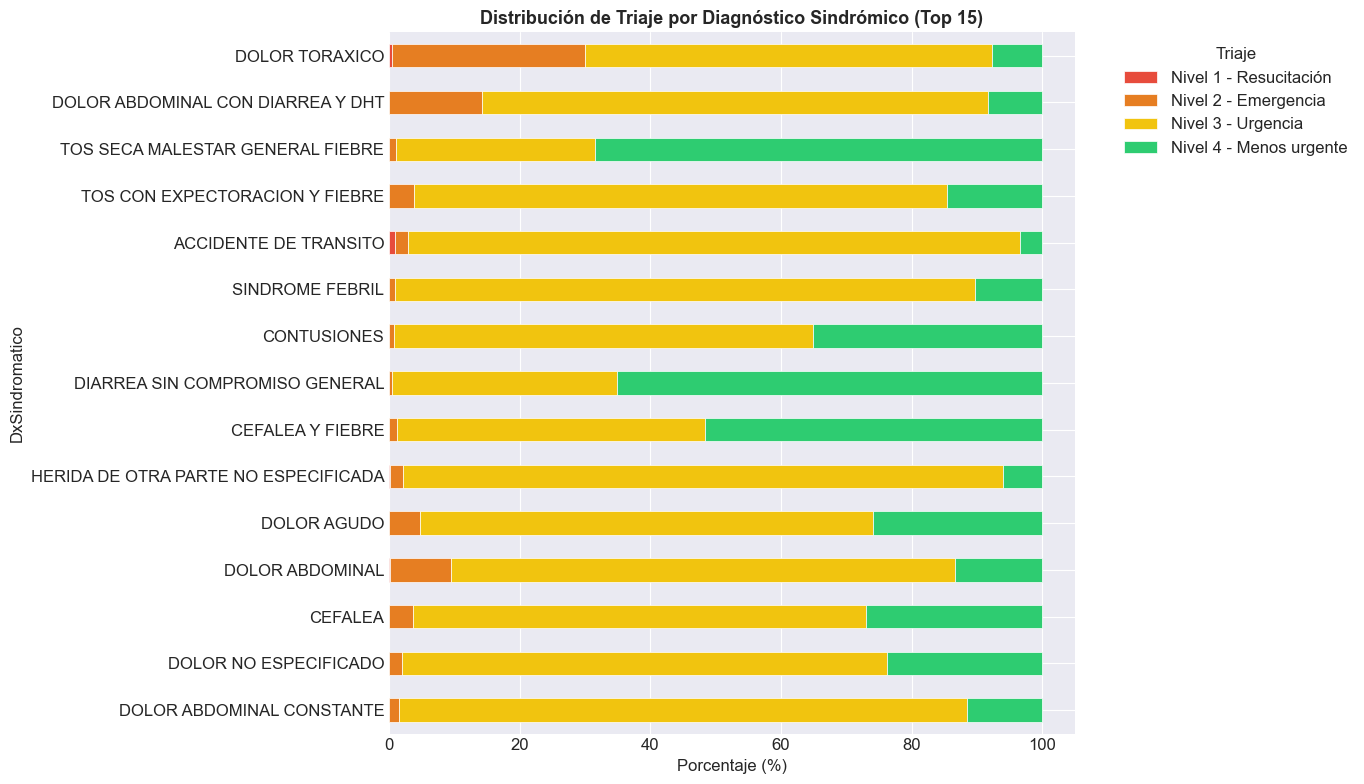

In [10]:
# Relación entre triaje y DxSindromatico (tabla cruzada top 15)
top15_dx = dx_counts.head(15).index
df_cross = df_clean[df_clean['DxSindromatico'].isin(top15_dx)]
cross_tab = pd.crosstab(df_cross['DxSindromatico'], df_cross['Triage'], normalize='index') * 100
cross_tab = cross_tab.loc[top15_dx]

fig, ax = plt.subplots(figsize=(14, 8))
cross_tab.plot(kind='barh', stacked=True, ax=ax, 
              color=[TRIAGE_COLORS[c] for c in cross_tab.columns],
              edgecolor='white', linewidth=0.5)
ax.set_xlabel('Porcentaje (%)')
ax.set_title('Distribución de Triaje por Diagnóstico Sindrómico (Top 15)', fontweight='bold', fontsize=13)
ax.legend(title='Triaje', labels=[f'Nivel {c} - {TRIAGE_NAMES.get(c, "")}' for c in cross_tab.columns],
         bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('../outputs/02_triage_vs_dxsindromatico.png', dpi=150, bbox_inches='tight')
plt.show()

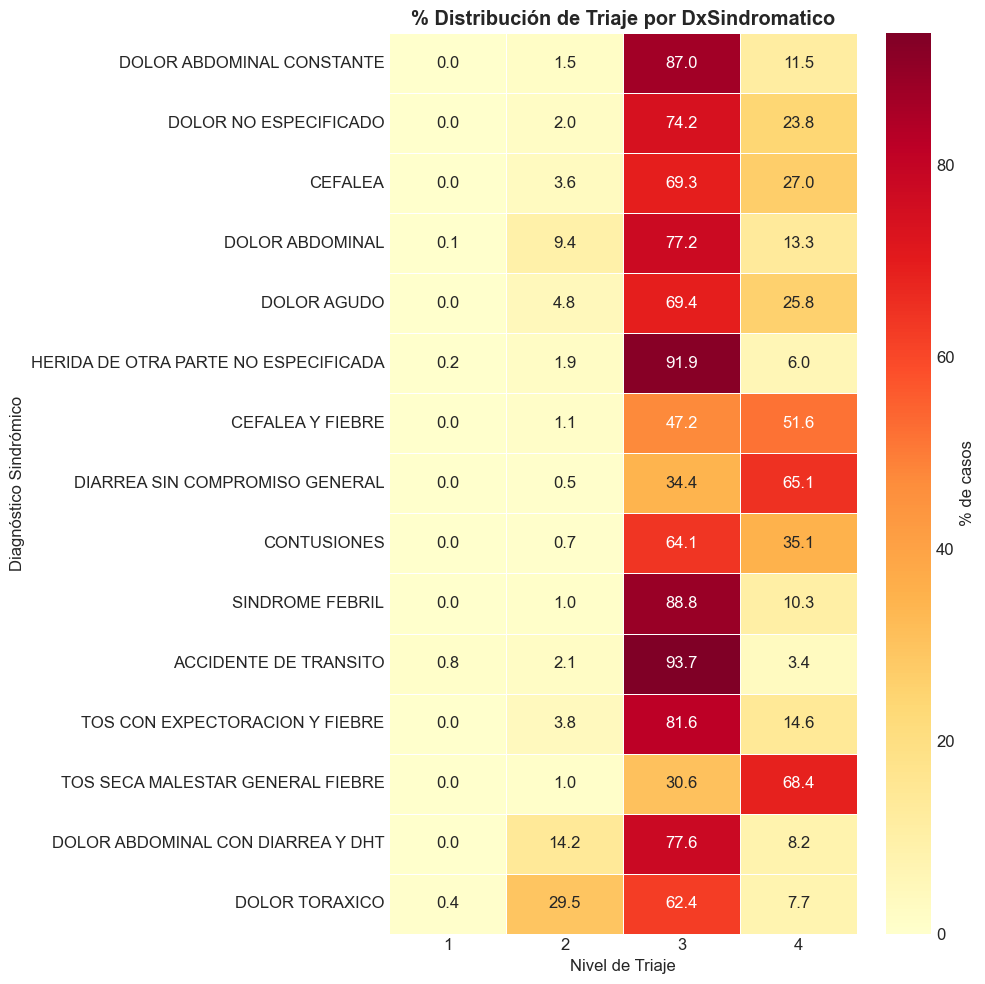

In [11]:
# Heatmap de la tabla cruzada
fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(cross_tab, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, 
           linewidths=0.5, cbar_kws={'label': '% de casos'})
ax.set_title('% Distribución de Triaje por DxSindromatico', fontweight='bold')
ax.set_xlabel('Nivel de Triaje')
ax.set_ylabel('Diagnóstico Sindrómico')
plt.tight_layout()
plt.savefig('../outputs/02_heatmap_triage_dx.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Perfil Demográfico

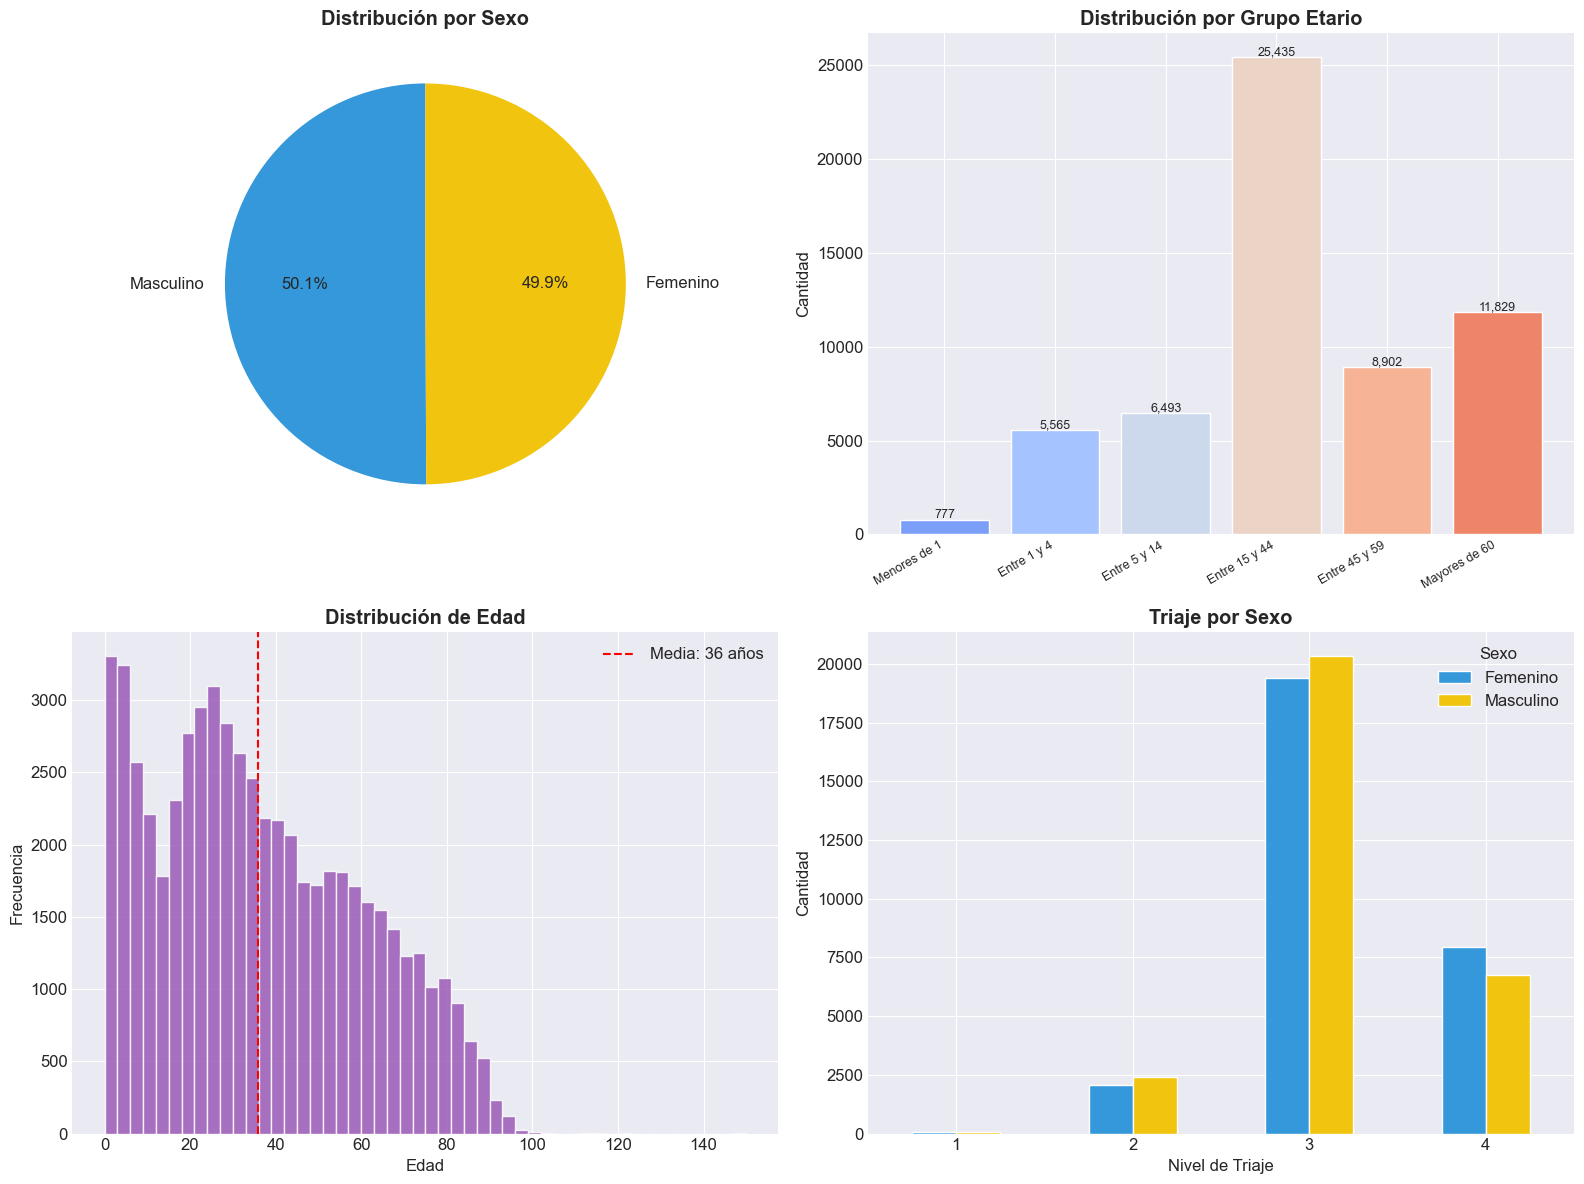

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Sexo
sexo_counts = df_clean['Sexo'].value_counts()
axes[0, 0].pie(sexo_counts.values, labels=sexo_counts.index, autopct='%1.1f%%', 
              colors=[COLORS[4], COLORS[2]], startangle=90, textprops={'fontsize': 12})
axes[0, 0].set_title('Distribución por Sexo', fontweight='bold')

# Grupo Etario
grupo_order = ['Menores de 1', 'Entre 1 y 4', 'Entre 5 y 14', 'Entre 15 y 44', 'Entre 45 y 59', 'Mayores de 60']
grupo_counts = df_clean['GrupoEtario1'].value_counts().reindex(grupo_order)
bars = axes[0, 1].bar(range(len(grupo_counts)), grupo_counts.values, 
                      color=plt.cm.coolwarm(np.linspace(0.2, 0.8, len(grupo_counts))), 
                      edgecolor='white')
axes[0, 1].set_xticks(range(len(grupo_counts)))
axes[0, 1].set_xticklabels(grupo_counts.index, rotation=30, ha='right', fontsize=9)
axes[0, 1].set_ylabel('Cantidad')
axes[0, 1].set_title('Distribución por Grupo Etario', fontweight='bold')
for bar, val in zip(bars, grupo_counts.values):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, val + 100, f'{val:,}', ha='center', fontsize=9)

# Distribución de edad
axes[1, 0].hist(df_clean['Edad'], bins=50, color=COLORS[5], edgecolor='white', alpha=0.85)
axes[1, 0].set_xlabel('Edad')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Distribución de Edad', fontweight='bold')
axes[1, 0].axvline(df_clean['Edad'].mean(), color='red', linestyle='--', 
                   label=f'Media: {df_clean["Edad"].mean():.0f} años')
axes[1, 0].legend()

# Triaje por sexo
sex_triage = pd.crosstab(df_clean['Triage'], df_clean['Sexo'])
sex_triage.plot(kind='bar', ax=axes[1, 1], color=[COLORS[4], COLORS[2]], edgecolor='white')
axes[1, 1].set_xlabel('Nivel de Triaje')
axes[1, 1].set_ylabel('Cantidad')
axes[1, 1].set_title('Triaje por Sexo', fontweight='bold')
axes[1, 1].legend(title='Sexo')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../outputs/02_perfil_demografico.png', dpi=150, bbox_inches='tight')
plt.show()

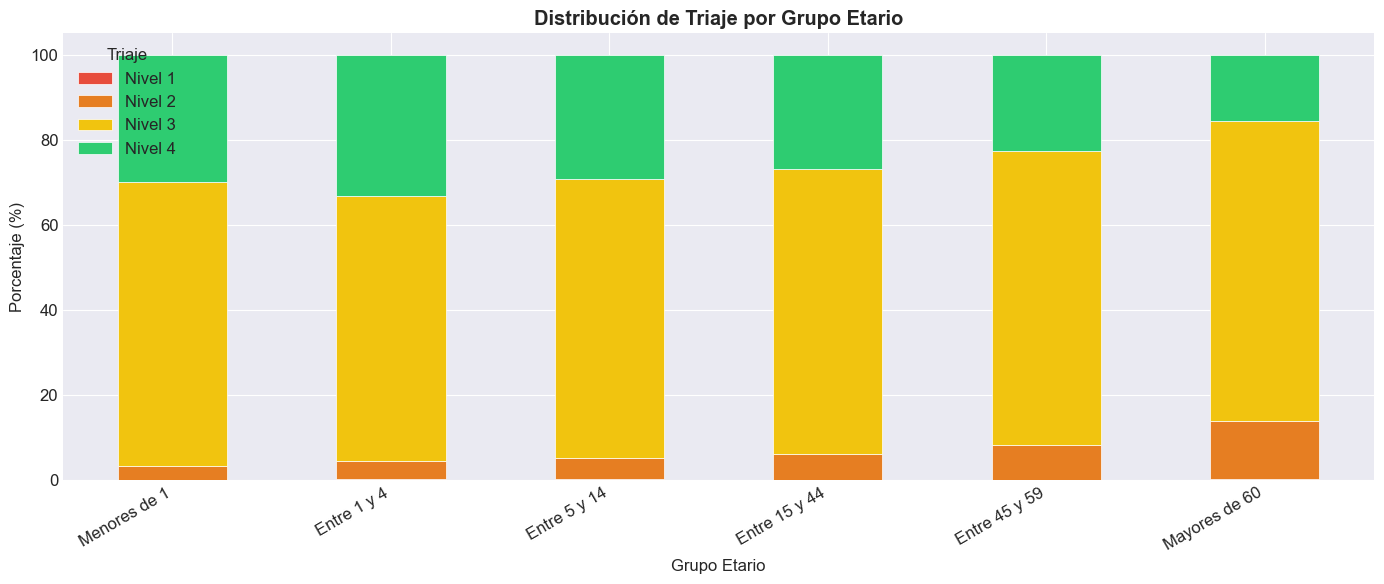

In [13]:
# Triaje por grupo etario
fig, ax = plt.subplots(figsize=(14, 6))
grupo_triage = pd.crosstab(df_clean['GrupoEtario1'], df_clean['Triage'], normalize='index') * 100
grupo_triage = grupo_triage.reindex(grupo_order)

grupo_triage.plot(kind='bar', stacked=True, ax=ax,
                 color=[TRIAGE_COLORS[c] for c in grupo_triage.columns],
                 edgecolor='white', linewidth=0.5)
ax.set_xlabel('Grupo Etario')
ax.set_ylabel('Porcentaje (%)')
ax.set_title('Distribución de Triaje por Grupo Etario', fontweight='bold')
ax.legend(title='Triaje', labels=[f'Nivel {c}' for c in grupo_triage.columns])
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../outputs/02_triage_por_grupo_etario.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Análisis Temporal

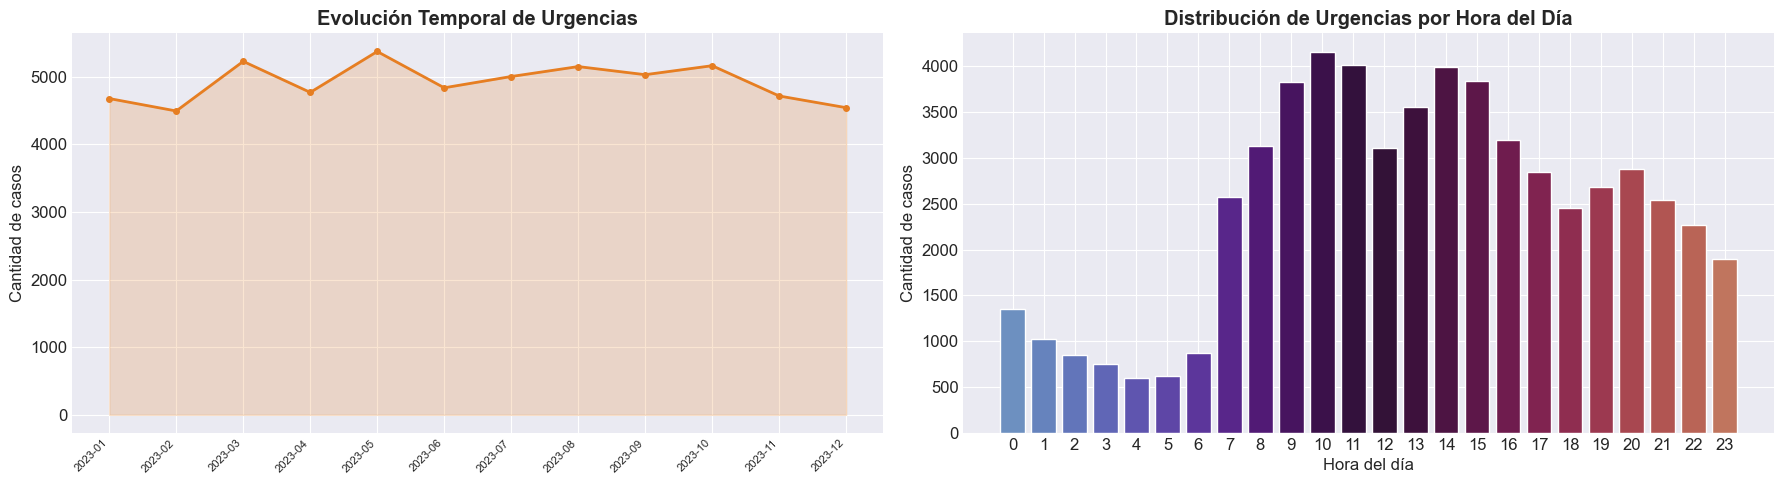

In [14]:
# Tendencia temporal
df_clean['mes'] = df_clean['FechaIngreso'].dt.to_period('M')
mensual = df_clean.groupby('mes').size()

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Casos por mes
axes[0].plot(range(len(mensual)), mensual.values, color=COLORS[1], linewidth=2, marker='o', markersize=4)
axes[0].fill_between(range(len(mensual)), mensual.values, alpha=0.2, color=COLORS[1])
axes[0].set_xticks(range(0, len(mensual), max(1, len(mensual)//12)))
axes[0].set_xticklabels([str(m) for m in mensual.index[::max(1, len(mensual)//12)]], rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Cantidad de casos')
axes[0].set_title('Evolución Temporal de Urgencias', fontweight='bold')

# Casos por hora del día
df_clean['hora'] = df_clean['FechaIngreso'].dt.hour
hora_counts = df_clean.groupby('hora').size()
axes[1].bar(hora_counts.index, hora_counts.values, color=plt.cm.twilight(np.linspace(0.2, 0.8, 24)), edgecolor='white')
axes[1].set_xlabel('Hora del día')
axes[1].set_ylabel('Cantidad de casos')
axes[1].set_title('Distribución de Urgencias por Hora del Día', fontweight='bold')
axes[1].set_xticks(range(24))

plt.tight_layout()
plt.savefig('../outputs/02_analisis_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Unidad de Atención

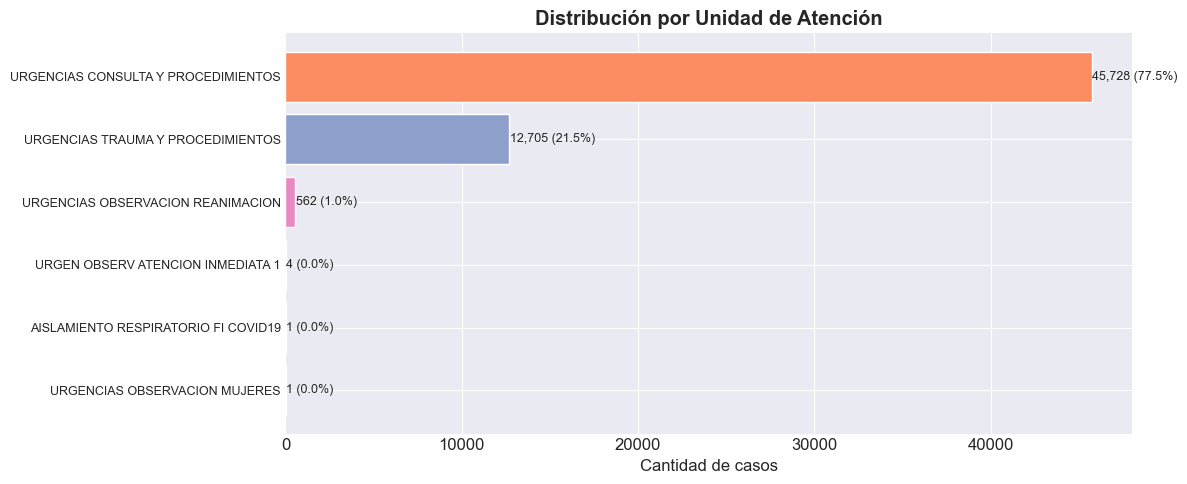

In [15]:
# Distribución por unidad
unidad_counts = df_clean['Unidad'].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(range(len(unidad_counts)), unidad_counts.values, 
              color=plt.cm.Set2(np.linspace(0.2, 0.8, len(unidad_counts))), edgecolor='white')
ax.set_yticks(range(len(unidad_counts)))
ax.set_yticklabels(unidad_counts.index, fontsize=9)
ax.set_xlabel('Cantidad de casos')
ax.set_title('Distribución por Unidad de Atención', fontweight='bold')
ax.invert_yaxis()

for bar, val in zip(bars, unidad_counts.values):
    ax.text(val + 50, bar.get_y() + bar.get_height()/2, f'{val:,} ({val/len(df_clean)*100:.1f}%)', 
           va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/02_unidad_atencion.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Conclusiones del EDA

### Hallazgos principales:
1. **Triaje desbalanceado**: El 67% de pacientes son nivel 3 (Urgencia), seguido por 25% nivel 4 (Menos urgente)
2. **Triaje 0 y 5 excluidos**: Solo 24 registros (0.04%), insuficientes para entrenamiento confiable
3. **Diagnósticos más comunes**: Dolor abdominal, cefalea, dolor agudo, traumas — patologías típicas de urgencias
4. **Distribución demográfica equilibrada**: ~50/50 en sexo, predominan adultos jóvenes (15-44 años)
5. **Relación triaje-diagnóstico**: Ciertos diagnósticos tienen distribuciones de triaje específicas (ej: trauma → nivel 2-3)

### Para el modelo de triaje:
- Aplicar **SMOTE** o **class_weight='balanced'** para manejar desbalance
- Usar `DxSindromatico`, `Sexo`, `Edad`, `GrupoEtario`, `Unidad` como features principales

In [16]:
# Resumen final
print('=' * 60)
print('📋 RESUMEN DEL EDA - MORBILIDAD URGENCIAS')
print('=' * 60)
print(f'Total registros originales: {len(df):,}')
print(f'Registros después de limpieza (sin triaje 0/5): {len(df_clean):,}')
print(f'Niveles de triaje válidos: {sorted(df_clean["Triage"].unique())}')
print(f'Diagnósticos sindrómicos únicos: {df_clean["DxSindromatico"].nunique()}')
print(f'Diagnósticos finales únicos: {df_clean["NombreDiagnostico"].nunique()}')
print(f'Rango de edad: {df_clean["Edad"].min()} - {df_clean["Edad"].max()}')
print('=' * 60)

📋 RESUMEN DEL EDA - MORBILIDAD URGENCIAS
Total registros originales: 59,025
Registros después de limpieza (sin triaje 0/5): 59,001
Niveles de triaje válidos: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Diagnósticos sindrómicos únicos: 297
Diagnósticos finales únicos: 1948
Rango de edad: 0 - 150
